In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv("urdu_emotions.csv")

# Basic info
print("Total rows:", len(df))
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Total rows: 20

Column names: ['text', 'emotion']

First 5 rows:


,text,emotion
0,میں بہت خوش ہوں,happy
1,آج کا دن بہت اچھا تھا,happy
2,مجھے بہت خوشی ہوئی,happy
3,یہ خبر سن کر دل خوش ہوگیا,happy
4,آج بہت مزہ آیا,happy


Emotion counts:
emotion
happy      5
angry      4
sad        4
neutral    4
fear       3
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_13136\1794884896.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")


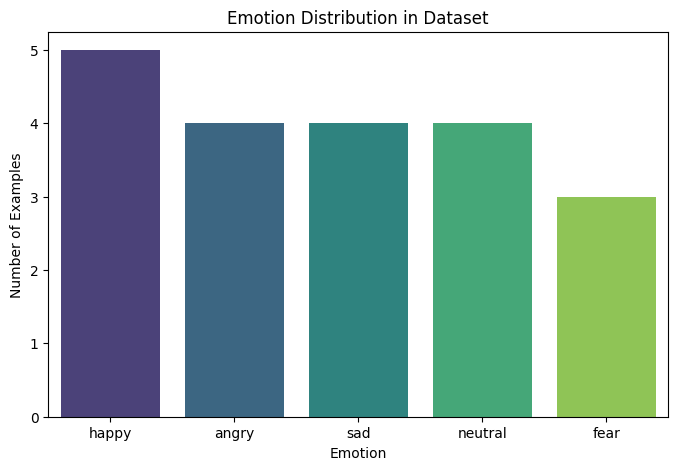

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count each emotion
emotion_counts = df['emotion'].value_counts()
print("Emotion counts:")
print(emotion_counts)

# Plot it
plt.figure(figsize=(8, 5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")
plt.title("Emotion Distribution in Dataset")
plt.xlabel("Emotion")
plt.ylabel("Number of Examples")
plt.show()

In [3]:
# Adding more examples to make training better
more_data = {
    "text": [
        # Happy (خوشی)
        "آج بہت اچھا دن ہے",
        "میری خواہش پوری ہو گئی",
        "یہ میری زندگی کا بہترین لمحہ ہے",
        "دوستوں کے ساتھ وقت گزارنا بہت اچھا لگتا ہے",
        "امتحان میں کامیابی ملی",
        "گھر میں خوشی کا ماحول ہے",

        # Sad (اداسی)
        "کاش وہ دن واپس آ جاتے",
        "دل بہت بھاری ہے آج",
        "یہ خبر سن کر رونا آ گیا",
        "تنہائی بہت تکلیف دہ ہوتی ہے",
        "بہت یاد آتے ہیں وہ لوگ",

        # Angry (غصہ)
        "یہ ناانصافی برداشت نہیں ہوتی",
        "کیوں ہمیشہ مجھ پر ہی الزام لگتا ہے",
        "اتنا جھوٹ کیوں بولتے ہیں",
        "یہ سب غلط ہو رہا ہے",
        "بالکل بھی صحیح نہیں کیا انہوں نے",

        # Fear (ڈر)
        "رات کو اکیلے جانے سے ڈر لگتا ہے",
        "امتحان کا نتیجہ سوچ کر ڈر لگتا ہے",
        "آگے کیا ہوگا معلوم نہیں",
        "اندھیرے میں بہت خوف آتا ہے",

        # Neutral (عام)
        "آج دفتر گیا اور کام کیا",
        "کھانا کھایا اور سو گیا",
        "باہر موسم ٹھیک ہے",
        "کل اسکول جانا ہے",
        "گھر پر بیٹھا ہوں"
    ],
    "emotion": [
        "happy", "happy", "happy", "happy", "happy", "happy",
        "sad", "sad", "sad", "sad", "sad",
        "angry", "angry", "angry", "angry", "angry",
        "fear", "fear", "fear", "fear",
        "neutral", "neutral", "neutral", "neutral", "neutral"
    ]
}

# Combine with original data
df_new = pd.DataFrame(more_data)
df_combined = pd.concat([df, df_new], ignore_index=True)

# Save it
df_combined.to_csv("urdu_emotions.csv", index=False)

print(f" Dataset expanded!")
print(f"Total rows now: {len(df_combined)}")
print("\nEmotion counts:")
print(df_combined['emotion'].value_counts())

 Dataset expanded!
Total rows now: 45

Emotion counts:
emotion
happy      11
angry       9
sad         9
neutral     9
fear        7
Name: count, dtype: int64


In [4]:
# Create label mapping
label2id = {
    "happy": 0,
    "sad": 1,
    "angry": 2,
    "fear": 3,
    "neutral": 4
}

id2label = {v: k for k, v in label2id.items()}

# Add numeric labels to dataframe
df_combined['label'] = df_combined['emotion'].map(label2id)

print("Label mapping:")
print(label2id)
print("\nYour data now looks like:")
print(df_combined.head(10))

Label mapping:
{'happy': 0, 'sad': 1, 'angry': 2, 'fear': 3, 'neutral': 4}

Your data now looks like:
                        text emotion  label
0            میں بہت خوش ہوں   happy      0
1      آج کا دن بہت اچھا تھا   happy      0
2         مجھے بہت خوشی ہوئی   happy      0
3  یہ خبر سن کر دل خوش ہوگیا   happy      0
4             آج بہت مزہ آیا   happy      0
5      مجھے بہت غصہ آ رہا ہے   angry      2
6            یہ بالکل غلط ہے   angry      2
7       یہ سن کر بہت غصہ آیا   angry      2
8        اتنی بے انصافی کیوں   angry      2
9          مجھے ڈر لگ رہا ہے    fear      3


In [5]:
from sklearn.model_selection import train_test_split

# Split the data
train_df, test_df = train_test_split(
    df_combined,
    test_size=0.2,        # 20% for testing
    random_state=42,      # makes split same every time
    stratify=df_combined['label']  # keeps emotion balance equal
)

# Reset index
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training examples: {len(train_df)}")
print(f"Testing examples:  {len(test_df)}")
print("\nTrain emotion counts:")
print(train_df['emotion'].value_counts())

Training examples: 36
Testing examples:  9

Train emotion counts:
emotion
happy      9
neutral    7
angry      7
sad        7
fear       6
Name: count, dtype: int64


In [6]:
from transformers import AutoTokenizer

print("Downloading tokenizer... (this may take 5 minutes)")

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

print(" Tokenizer downloaded!")

# Test it with an Urdu sentence
sample = "میں بہت خوش ہوں"
tokens = tokenizer(sample, return_tensors="pt")

print(f"\nSample Urdu text: {sample}")
print(f"Tokenized into {tokens['input_ids'].shape[1]} tokens")
print(" Model understands Urdu!")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 Tokenizer downloaded!

Sample Urdu text: میں بہت خوش ہوں
Tokenized into 6 tokens
 Model understands Urdu!
